# Interpreting the coefficients - global explanations

[Machine Learning Interpretability course](https://www.trainindata.com/p/machine-learning-interpretability)

In this notebook, we will interpret the values of the coefficients and how they affect the probability of the outcome.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Load data

To obtain the data, check the folder `prepare-data` in this repo, or section 2 in the course.

In [2]:
# load titanic dataset

df = pd.read_csv('../titanic.csv')

df.head()

,pclass,sibsp,parch,survived,sex_female,embarked_S,embarked_C,cabin_B,cabin_C,cabin_E,cabin_D,cabin_A,cabin_M,cabin_G
0,1,0,0,1,1,1,0,1,0,0,0,0,0,0
1,1,1,2,1,0,1,0,0,1,0,0,0,0,0
2,1,1,2,0,1,1,0,0,1,0,0,0,0,0
3,1,1,2,0,0,1,0,0,1,0,0,0,0,0
4,1,1,2,0,1,1,0,0,1,0,0,0,0,0


In [3]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("survived", axis=1),
    df["survived"],
    test_size=0.15,
    random_state=1,
)

X_train.shape, X_test.shape

((1112, 13), (197, 13))

In [4]:
# scale the variables
scaler = StandardScaler().set_output(transform="pandas")

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# display top 5 rows
X_train.head()

,pclass,sibsp,parch,sex_female,embarked_S,embarked_C,cabin_B,cabin_C,cabin_E,cabin_D,cabin_A,cabin_M,cabin_G
1021,0.834271,-0.474139,-0.456096,-0.739319,0.666450,-0.516251,-0.22592,-0.280294,-0.182913,-0.193167,-0.128271,0.539927,-0.067206
512,-0.367425,0.469050,-0.456096,-0.739319,-1.500487,1.937043,-0.22592,-0.280294,-0.182913,-0.193167,-0.128271,0.539927,-0.067206
957,0.834271,2.355428,0.745749,1.352596,0.666450,-0.516251,-0.22592,-0.280294,-0.182913,-0.193167,-0.128271,0.539927,-0.067206
1066,0.834271,-0.474139,-0.456096,-0.739319,-1.500487,1.937043,-0.22592,-0.280294,-0.182913,-0.193167,-0.128271,0.539927,-0.067206
1259,0.834271,-0.474139,-0.456096,-0.739319,0.666450,-0.516251,-0.22592,-0.280294,-0.182913,-0.193167,-0.128271,0.539927,-0.067206


In [5]:
# We know from previous notebooks that these features are non-
# predictive (their coefficients are not significantly 
# different from 0.)

non_predictive = ["parch", "embarked_S", "embarked_C", "cabin_C", 
                  "cabin_B", "cabin_E", "cabin_D", "cabin_A", "cabin_G"]

# So we take them out
X_train.drop(non_predictive, axis=1, inplace=True)
X_test.drop(non_predictive, axis=1, inplace=True)

## Scikit-learn

In [7]:
# fit model

# important to remove the penalty for unregularized regression.
logit = LogisticRegression(l1_ratio=0, random_state=1)

logit.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver b

## Odds ratio

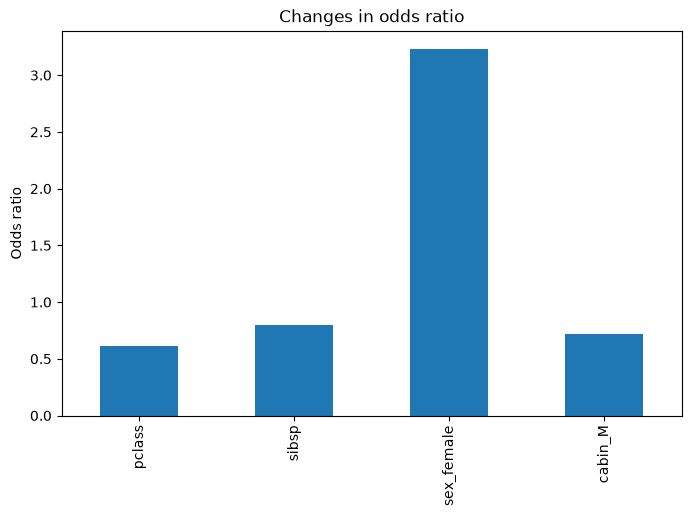

In [8]:
# Calculate and plot the odds ratio

s = pd.Series(
    np.exp(logit.coef_[0]),
    index=logit.feature_names_in_,
)

s.plot.bar(figsize=(8,5))
plt.ylabel("Odds ratio")
plt.title("Changes in odds ratio")
plt.show()

Being female, increased the probability of survival 3 times.


The remaining variables reduced the probability of survival by ~half.

## Coefficient sign and direction

Visualize how the coefficients affect the probability of survival, and with the error, we know if we can trust them.

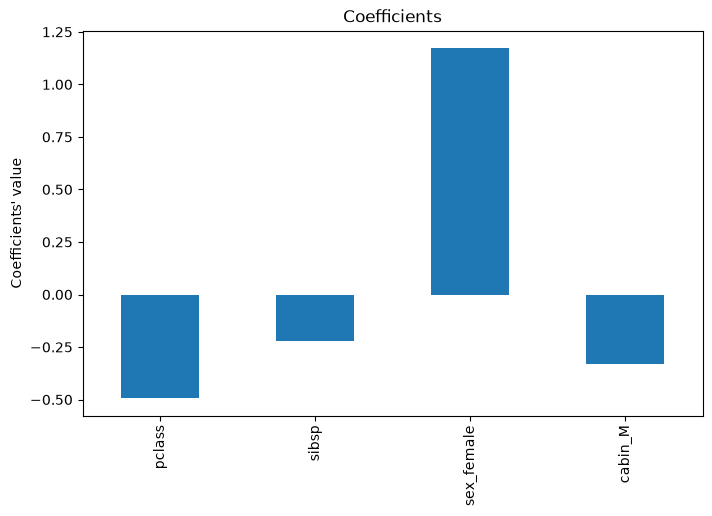

In [9]:
# Coefficients value

s = pd.Series(
    logit.coef_[0],
    index=logit.feature_names_in_,
)

s.plot.bar(figsize=(8,5))
plt.ylabel("Coefficients' value")
plt.title("Coefficients")
plt.show()

By looking at the coefficient sign and absolute magnitude we conclude that being female increases the probability of survival. 

Increasing the value of all other variables decreases the probability of survival.

The standard error among the coefficients is very similar.

## Coefficient absolute value - feature importance

This is what we normally use as a measure of feature importance.

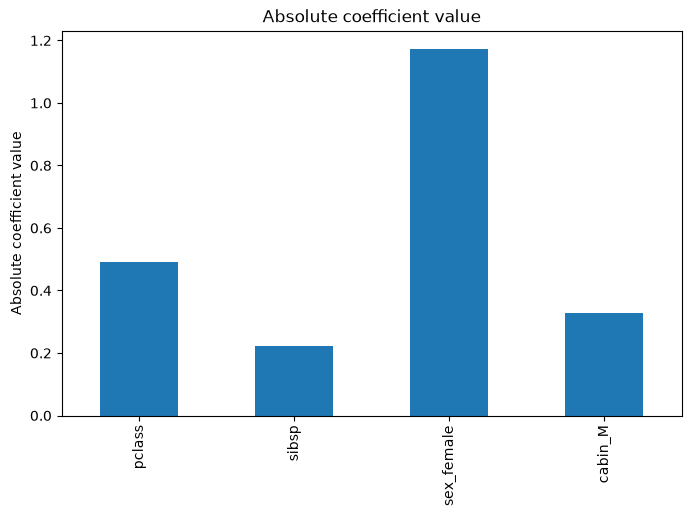

In [10]:
# Plot mean coefficient and std

s = pd.Series(
    np.abs(logit.coef_[0]),
    index=logit.feature_names_in_,
)

s.plot.bar(figsize=(8,5))
plt.ylabel("Absolute coefficient value")
plt.title("Absolute coefficient value")
plt.show()

## z (Wald statistic)

We need the error, so here I calculate it experimentally.

In [11]:
W = np.diagflat(np.prod(logit.predict_proba(X_train), axis=1))

X = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

cov_m = np.linalg.inv(np.dot(np.dot(X.T, W), X))

se = np.sqrt(np.diag(cov_m))

z = logit.coef_[0] / se[1:]

z

array([-4.62995899, -2.50291793, 15.16812331, -3.17690601])

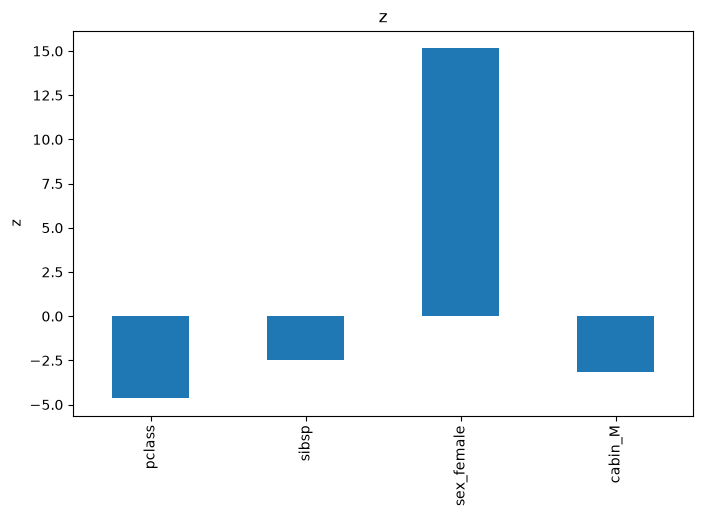

In [12]:
# estimate and plot z

s = pd.Series(
    z,
    index=logit.feature_names_in_,
)

s.plot.bar(figsize=(8,5))
plt.ylabel("z")
plt.title("z")
plt.show()

- females were 3 times more likely to survive than men.
- richer people (travelling in class 1) were more likely to survive than poorer people (pclass decreases probability of survival)
- having children or spouse (sibsp) also decreased, for some reason, the probability of survival.